<a href="https://colab.research.google.com/github/zombimann/Mathematical-video-animations-and-visualization/blob/main/Quantum_Physics_Higgs_Mechanism_Feynman_Diagrams.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Higgs Mechanism — Scientific Animation

### Author: Mugambi Ndwiga
**Instagram:** [@craftsandengineering](https://www.instagram.com/craftsandengineering)

---

## Project Overview
This project generates a polished, self-contained educational MP4 animation explaining the **Higgs Mechanism**, electroweak symmetry breaking, and key particle physics concepts. The animation is built entirely using `matplotlib` and `numpy` in Google Colab.

## Animation Scenes
1.  **The Higgs Field:** Visualizing how particles acquire inertial mass through field interaction.
2.  **Spontaneous Symmetry Breaking:** The 'Mexican Hat' potential and the vacuum settling into a stable state.
3.  **Gluon Fusion:** The dominant Higgs production mode at the LHC via virtual top-quark loops.
4.  **Higgs Decay to Photons (H → ̳̳):** A key discovery channel involving quantum loops.
5.  **The Golden Channel (H → ZZ → 4ℓ):** The remarkably clean signature of four charged leptons.
6.  **Electroweak Symmetry Breaking:** How the Higgs field differentiates the electroweak force into electromagnetism and the weak interaction.

## Technical Specifications
- **Resolution:** 1280×720 (720p)
- **Frame Rate:** 30 FPS
- **Runtime:** ~54 seconds
- **Libraries:** Matplotlib, NumPy
- **Output:** `higgs_mechanism.mp4`

---

## Addendum: Experimental 3D Visualizations
In addition to the standard 2D educational short, this notebook contains high-fidelity 3D visualizations exploring the complex geometry of the Higgs sector:

*   **3D Mexican Hat Potential:** A spatial representation of the Higgs potential $V(\phi)$, demonstrating the transition from a symmetric unstable peak to the degenerate 'circle of minima' that defines the vacuum expectation value (VEV).
*   **3D Gluon Fusion (LHC):** A visualization of non-planar gluon interaction, showing the convergence of field vectors into the virtual top-quark loop to produce the Higgs scalar in a 3D volume.
*   **Kinematic Perspective:** These scenes use rotating camera perspectives to provide better spatial intuition for the symmetry-breaking mechanism.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

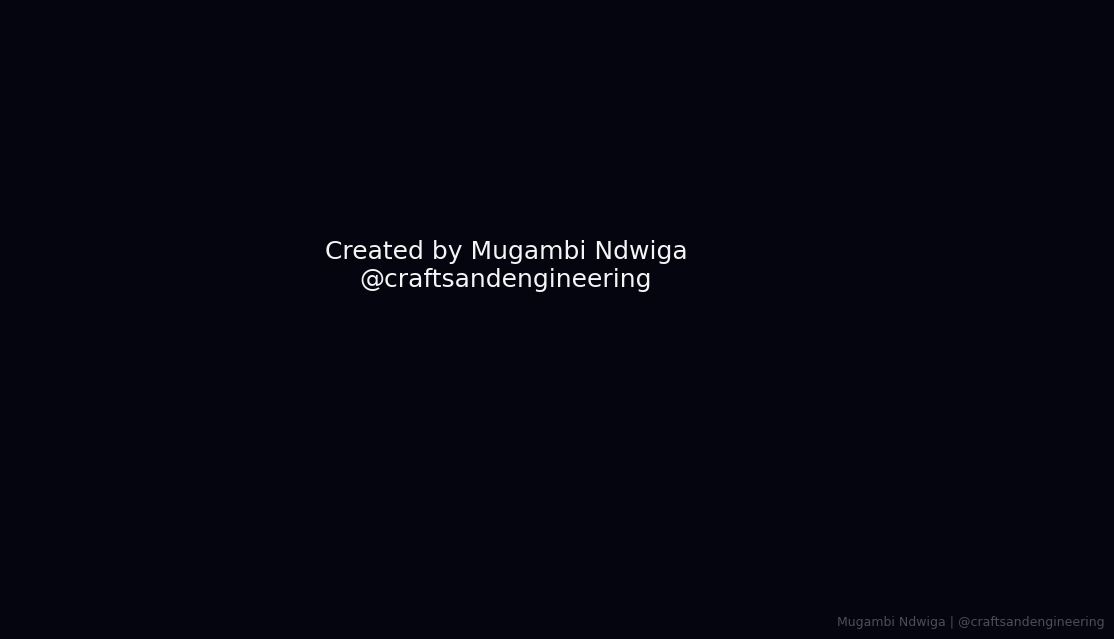

In [2]:
"""
The Higgs Mechanism — Scientific Animation

Author:
Mugambi Ndwiga

Instagram:
@craftsandengineering

Description:
Educational scientific animation explaining the Higgs field,
electroweak symmetry breaking, Higgs boson production,
and Higgs decay channels using modern particle physics.

Platform:
Google Colab

Libraries:
matplotlib, numpy
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib.patches as patches
from IPython.display import HTML
from base64 import b64encode
import google.colab.files

# --- GLOBAL CONFIG ---
BG_COLOR = '#050510'
HIGGS_COLOR = '#ffb300'
TOP_COLOR = '#ff7043'
GLUON_COLOR = '#76ff03'
W_COLOR = '#d500f9'
Z_COLOR = '#aa66ff'
PHOTON_COLOR = '#ffd740'
FERMION_COLOR = '#80deea'
TEXT_COLOR = '#f5f5f5'
FLASH_COLOR = '#ffffff'

FPS = 30
DURATION = 54  # seconds
TOTAL_FRAMES = DURATION * FPS
SCENE_COUNT = 6

# Helper for easing
def ease_in_out(t):
    return 0.5 - 0.5 * np.cos(np.pi * np.clip(t, 0, 1))

def lerp(a, b, t):
    return a + (b - a) * t

def get_wavy_line(p1, p2, freq=10, amp=0.1, t_max=1.0):
    dist = np.linalg.norm(p2 - p1)
    num_points = int(50 * dist)
    t = np.linspace(0, t_max, num_points)
    line = np.zeros((num_points, 2))

    unit = (p2 - p1) / dist
    perp = np.array([-unit[1], unit[0]])

    for i, ti in enumerate(t):
        pos = p1 + unit * ti * dist
        offset = perp * amp * np.sin(freq * ti * dist)
        line[i] = pos + offset
    return line

def get_zigzag_line(p1, p2, freq=12, amp=0.15, t_max=1.0):
    dist = np.linalg.norm(p2 - p1)
    num_points = 100
    t = np.linspace(0, t_max, num_points)
    line = np.zeros((num_points, 2))
    unit = (p2 - p1) / dist
    perp = np.array([-unit[1], unit[0]])
    for i, ti in enumerate(t):
        pos = p1 + unit * ti * dist
        # Triangle wave
        offset = perp * amp * (abs(( (ti*dist*freq) % 4) - 2) - 1)
        line[i] = pos + offset
    return line

# --- ANIMATION ENGINE ---
fig, ax = plt.subplots(figsize=(12.8, 7.2), dpi=100)
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)
ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-3.5, 3.5)
ax.axis('off')

# Persistent Watermark
fig.text(0.98, 0.02, "Mugambi Ndwiga | @craftsandengineering",
         color=TEXT_COLOR, alpha=0.3, fontsize=9, ha='right', va='bottom')

def init():
    ax.clear()
    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-3.5, 3.5)
    ax.axis('off')
    return []

def update(frame):
    ax.clear()
    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-3.5, 3.5)
    ax.axis('off')

    # Determine timing
    t_global = frame / TOTAL_FRAMES
    scene_duration_frames = 8 * FPS
    scene_idx = int(frame // scene_duration_frames)
    t_scene = (frame % scene_duration_frames) / scene_duration_frames

    # Title Card logic (Intro/Outro)
    if frame < 30:
        draw_title_card(t_scene)
    elif frame > TOTAL_FRAMES - 30:
        draw_end_card(1.0)
    else:
        # Correct indices for the 6 actual content scenes
        actual_scene = int((frame-30) // (9 * FPS))
        actual_t = ((frame-30) % (9 * FPS)) / (9 * FPS)

        scenes = [draw_scene_1, draw_scene_2, draw_scene_3, draw_scene_4, draw_scene_5, draw_scene_6]
        if actual_scene < len(scenes):
            scenes[actual_scene](actual_t)

    return []

def draw_title_card(t):
    alpha = ease_in_out(t)
    ax.text(0, 0.5, "The Higgs Mechanism", color=TEXT_COLOR, size=24, ha='center', alpha=alpha)
    ax.text(0, 0.0, "Mass, Symmetry Breaking, and the Higgs Boson", color=TEXT_COLOR, size=14, ha='center', alpha=alpha)
    ax.text(0, -1.0, "By: Mugambi Ndwiga | @craftsandengineering", color=HIGGS_COLOR, size=10, ha='center', alpha=alpha)

def draw_end_card(t):
    ax.text(0, 0, "Created by Mugambi Ndwiga\n@craftsandengineering", color=TEXT_COLOR, size=18, ha='center')

# SCENE 1: Higgs Field & Mass
def draw_scene_1(t):
    ax.text(0, 3, "The Higgs Field", color=TEXT_COLOR, size=18, ha='center')
    # Grid pulse
    grid_alpha = 0.05 + 0.03 * np.sin(t * 10)
    for x in np.linspace(-4, 4, 15):
        for y in np.linspace(-3, 3, 10):
            ax.plot(x, y, '.', color=HIGGS_COLOR, alpha=grid_alpha, markersize=2)

    # Quark propagation
    q_t = ease_in_out(np.clip(t*1.5, 0, 1))
    v_x = lerp(-3, 3, q_t)
    # Interaction at center
    if v_x < 0:
        ax.plot([-3, v_x], [0, 0], color=FERMION_COLOR, lw=1, alpha=0.6)
    else:
        ax.plot([-3, 0], [0, 0], color=FERMION_COLOR, lw=1, alpha=0.6)
        ax.plot([0, v_x], [0, 0], color=FERMION_COLOR, lw=2.5, alpha=1.0) # More substantial
        # Higgs emission
        h_t = np.clip((t-0.5)*2, 0, 1)
        if h_t > 0:
            ax.plot([0, 0], [0, h_t*2], '--', color=HIGGS_COLOR, lw=1.5)
            ax.text(0.2, h_t*2, "H", color=HIGGS_COLOR)
            ax.text(0.5, -0.5, "mass acquired", color=TEXT_COLOR, size=10, alpha=h_t)

    ax.text(0, -3, "The Higgs field gives elementary particles inertial mass", color=TEXT_COLOR, size=12, ha='center')

# SCENE 2: Mexican Hat
def draw_scene_2(t):
    ax.text(0, 3, "Spontaneous Symmetry Breaking", color=TEXT_COLOR, size=16, ha='center')
    x = np.linspace(-2, 2, 100)
    y = (x**2 - 1.2)**2
    ax.plot(x, y - 1, color=HIGGS_COLOR, alpha=0.8)

    ball_t = ease_in_out(np.clip(t*1.2, 0, 1))
    ball_x = lerp(0, 1.1, ball_t)
    ball_y = (ball_x**2 - 1.2)**2 - 1
    ax.plot(ball_x, ball_y, 'o', color=FLASH_COLOR, markersize=8)

    if ball_t > 0.9:
        ax.text(1.2, ball_y, "Symmetry broken", color=FLASH_COLOR, size=10)
        # Oscillation
        osc = 0.1 * np.sin(t*20)
        ax.annotate('', xy=(1.1, ball_y+0.5+osc), xytext=(1.1, ball_y-0.2), arrowprops=dict(arrowstyle='<->', color=HIGGS_COLOR))
        ax.text(1.3, ball_y+0.3, "Higgs excitation", color=HIGGS_COLOR, size=8)

# SCENE 3: Gluon Fusion
def draw_scene_3(t):
    ax.text(0, 3, "Gluon Fusion", color=TEXT_COLOR, size=16, ha='center')
    # Gluons
    g1 = get_zigzag_line(np.array([-3, 1]), np.array([-1, 0]), t_max=np.clip(t*2,0,1))
    g2 = get_zigzag_line(np.array([-3, -1]), np.array([-1, 0]), t_max=np.clip(t*2,0,1))
    ax.plot(g1[:,0], g1[:,1], color=GLUON_COLOR)
    ax.plot(g2[:,0], g2[:,1], color=GLUON_COLOR)

    # Loop
    if t > 0.4:
        lt = np.clip((t-0.4)*2, 0, 1)
        pts = np.array([[-1, 0], [0, 1], [0, -1], [-1, 0]])
        for i in range(3):
            seg_t = np.clip(lt*3 - i, 0, 1)
            p_start, p_end = pts[i], pts[i+1]
            curr = p_start + (p_end - p_start)*seg_t
            ax.plot([p_start[0], curr[0]], [p_start[1], curr[1]], color=TOP_COLOR, lw=2)

    if t > 0.8:
        ht = np.clip((t-0.8)*5, 0, 1)
        ax.plot([0, 0 + ht*2], [0, 0 + ht*1], '--', color=HIGGS_COLOR, lw=2)
        ax.text(1, 1, "H", color=HIGGS_COLOR)

# SCENE 4: H -> Gamma Gamma
def draw_scene_4(t):
    ax.text(0, 3, "H → ̳̳", color=TEXT_COLOR, size=16, ha='center')
    # Higgs
    ht = np.clip(t*2, 0, 1)
    ax.plot([-3, -3 + ht*2], [0, 0], '--', color=HIGGS_COLOR)

    # W loop (simplified square)
    if t > 0.5:
        wt = np.clip((t-0.5)*2, 0, 1)
        ax.add_patch(patches.Rectangle((-1, -0.5), 1, 1, fill=False, edgecolor=W_COLOR, lw=2, alpha=wt))

        # Photons
        pt = np.clip((t-0.8)*3, 0, 1)
        if pt > 0:
            p1 = get_wavy_line(np.array([0, 0.5]), np.array([2, 1.5]), t_max=pt)
            p2 = get_wavy_line(np.array([0, -0.5]), np.array([2, -1.5]), t_max=pt)
            ax.plot(p1[:,0], p1[:,1], color=PHOTON_COLOR)
            ax.plot(p2[:,0], p2[:,1], color=PHOTON_COLOR)

# SCENE 5: Golden Channel
def draw_scene_5(t):
    ax.text(0, 3, "The Golden Channel: H → ZZ → 4ℓ", color=TEXT_COLOR, size=16, ha='center')
    # Higgs
    ax.plot([-4, -2], [0, 0], '--', color=HIGGS_COLOR, alpha=np.clip(t*2,0,1))
    # Z bosons
    if t > 0.3:
        zt = np.clip((t-0.3)*2, 0, 1)
        ax.plot([-2, -2 + zt*1.5], [0, 1], color=Z_COLOR, lw=3)
        ax.plot([-2, -2 + zt*1.5], [0, -1], color=Z_COLOR, lw=3)
    # Leptons
    if t > 0.6:
        lt = np.clip((t-0.6)*2, 0, 1)
        offs = [[-0.5, 1.5], [-0.5, 0.5], [1, -0.5], [1, -1.5]]
        for i, dy in enumerate([1.5, 0.5, -0.5, -1.5]):
            ax.plot([-0.5, -0.5 + lt*1.5], [1 if i<2 else -1, dy], color=FERMION_COLOR)

# SCENE 6: EW Symmetry Breaking
def draw_scene_6(t):
    ax.text(0, 3, "Electroweak Symmetry Breaking", color=TEXT_COLOR, size=16, ha='center')
    ax.axvline(0, color=TEXT_COLOR, ls=':', alpha=0.3)

    ax.text(-2.2, 2, "High Energy (Symmetric)", color=TEXT_COLOR, ha='center', size=10)
    ax.text(2.2, 2, "Low Energy (Broken)", color=TEXT_COLOR, ha='center', size=10)

    # Left side
    for i, lbl in enumerate(['W1','W2','W3','B']):
        ax.text(-3, 1-i*0.6, lbl, color=FERMION_COLOR, alpha=0.7)

    # Right side appearing via ripple
    ripple_x = lerp(-1, 4, t)
    if ripple_x > 0:
        ax.axvline(ripple_x, color=HIGGS_COLOR, alpha=0.4)
        right_labels = [('W+', W_COLOR, '80 GeV'), ('W-', W_COLOR, '80 GeV'), ('Z0', Z_COLOR, '91 GeV'), ('̳', PHOTON_COLOR, '0')]
        for i, (lbl, col, mass) in enumerate(right_labels):
            if ripple_x > 1:
                ax.text(1, 1-i*0.6, lbl, color=col)
                ax.text(2.5, 1-i*0.6, mass, color=TEXT_COLOR, size=8, alpha=0.6)

ani = FuncAnimation(fig, update, frames=TOTAL_FRAMES, init_func=init, blit=True)

# Export
writer = FFMpegWriter(fps=FPS, metadata=dict(artist='Mugambi Ndwiga'), bitrate=2000)
output_file = 'higgs_mechanism.mp4'
ani.save(output_file, writer=writer)

# Display
mp4 = open(output_file,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
display(HTML(f''' <video width=960 controls autoplay loop> <source src="{data_url}" type="video/mp4"> </video>'''))

# Download
google.colab.files.download(output_file)


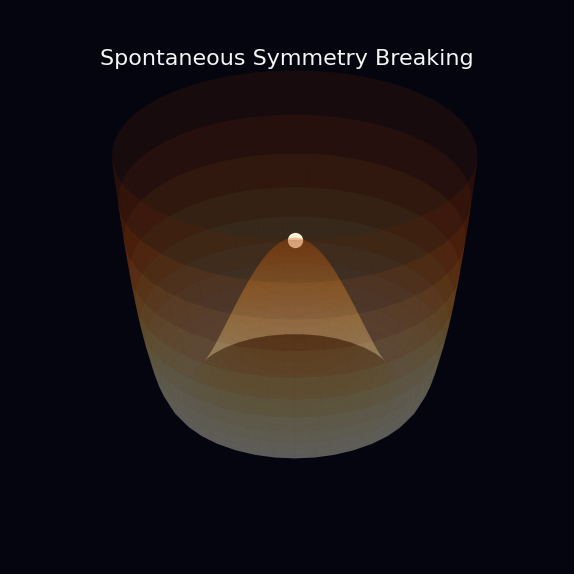

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML
from base64 import b64encode

# --- CONFIG ---
BG_COLOR = '#050510'
FPS = 30
SCENE_FRAMES = 150
TOTAL_FRAMES = SCENE_FRAMES * 2

fig = plt.figure(figsize=(12.8, 7.2), facecolor=BG_COLOR)
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor(BG_COLOR)

# Precompute Mexican Hat
r_hat = np.linspace(0, 1.5, 40)
theta_hat = np.linspace(0, 2*np.pi, 40)
R, TH = np.meshgrid(r_hat, theta_hat)
X_H = R * np.cos(TH)
Y_H = R * np.sin(TH)
Z_H = (R**2 - 1)**2

def update_combined(frame):
    ax.clear()
    ax.axis('off')

    if frame < SCENE_FRAMES:
        # --- SCENE 1: 3D POTENTIAL ---
        t = frame / SCENE_FRAMES
        ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.set_zlim(0, 1.5)
        ax.plot_surface(X_H, Y_H, Z_H, cmap='YlOrBr', alpha=0.2, antialiased=True)

        # Rolling particle
        cur_r = 1.0 * (1 - np.exp(-4*t))
        cur_th = t * 3
        px, py = cur_r * np.cos(cur_th), cur_r * np.sin(cur_th)
        pz = (cur_r**2 - 1)**2
        ax.plot([px], [py], [pz], 'o', color='#ffffff', markersize=10)

        ax.text2D(0.5, 0.9, "Spontaneous Symmetry Breaking", transform=ax.transAxes, color='#f5f5f5', size=16, ha='center')
        if t > 0.7: ax.text2D(0.5, 0.8, "Vacuum Expectation Value ≠ 0", transform=ax.transAxes, color='#ffb300', size=12, ha='center')
        ax.view_init(elev=30, azim=frame)

    else:
        # --- SCENE 2: 3D GLUON FUSION ---
        t = (frame - SCENE_FRAMES) / SCENE_FRAMES
        ax.set_xlim(-2, 2); ax.set_ylim(-2, 2); ax.set_zlim(-2, 2)

        # Incoming Gluons (3D ZigZags)
        for side in [1, -1]:
            pts = np.linspace(0, np.clip(t*2, 0, 1), 50)
            gx = -2 + pts * 1.5
            gy = side * (1 - pts)
            gz = side * (1 - pts) + 0.1 * np.sin(pts * 20)
            ax.plot(gx, gy, gz, color='#76ff03', lw=1.5)

        # Triangle Top Loop
        if t > 0.5:
            lt = np.clip((t-0.5)*2, 0, 1)
            lpts = np.array([[-0.5,0,0], [0,0.5,0.5], [0,-0.5,0.5], [-0.5,0,0]])
            for i in range(3):
                st = np.clip(lt*3-i, 0, 1)
                p1, p2 = lpts[i], lpts[i+1]
                curr = p1 + (p2-p1)*st
                ax.plot([p1[0], curr[0]], [p1[1], curr[1]], [p1[2], curr[2]], color='#ff7043', lw=2)

        if t > 0.8:
            ax.plot([0, 1.5], [0,0], [0.5, 0.5], '--', color='#ffb300', lw=2)
            ax.text(1.6, 0, 0.5, "Higgs (H)", color='#ffb300')

        ax.text2D(0.5, 0.9, "3D Gluon Fusion (LHC Production)", transform=ax.transAxes, color='#f5f5f5', size=16, ha='center')
        ax.view_init(elev=20, azim=frame*0.5)

    return []

ani_3d_film = FuncAnimation(fig, update_combined, frames=TOTAL_FRAMES, interval=40)
output_final = 'higgs_3d_film.mp4'
ani_3d_film.save(output_final, writer=FFMpegWriter(fps=30))

mp4_3d = open(output_final,'rb').read()
display(HTML(f'<video width=960 controls autoplay loop><source src="data:video/mp4;base64,{b64encode(mp4_3d).decode()}" type="video/mp4"></video>'))